In [ ]:
# import necessary images of celestial objects


Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Creating DataFrame

In [ ]:
df=pd.read_csv('/content/stellar_classification_new_file.csv')
df

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [ ]:
# read an google sheet file representing the colunm names
col_names=pd.read_excel('/content/Go through the uploaded file and identify the col....xlsx')

In [ ]:
col_names

,Column Name,Description
0,obj_ID,Unique object identifier in the photometric sy...
1,alpha,Right Ascension angle (at J2000 epoch).
2,delta,Declination angle (at J2000 epoch).
3,u,Ultraviolet filter (photometric system).
4,g,Green filter (photometric system).
5,r,Red filter (photometric system).
6,i,Near Infrared filter (photometric system).
7,z,Infrared filter (photometric system).
8,run_ID,Run Number used to identify the specific scan.
9,rerun_ID,Rerun Number specifying how the image was proc...


In [ ]:
df.shape

(100000, 18)

Exploratory Data Analysis.

In [ ]:
df.isna().sum()


,0
obj_ID,0
alpha,590
delta,593
u,632
g,555
r,613
i,605
z,0
run_ID,0
rerun_ID,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        99410 non-null   float64
 2   delta        99407 non-null   float64
 3   u            99368 non-null   float64
 4   g            99445 non-null   float64
 5   r            99387 non-null   float64
 6   i            99395 non-null   float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

In [ ]:
df.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,99410.000000,99407.000000,99368.000000,99445.000000,99387.000000,99395.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.644863,24.145105,21.980128,20.530679,19.646101,19.084550,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.499853,19.647506,31.869639,31.838434,1.854871,1.757752,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.509879,5.152477,20.352190,18.965250,18.136725,17.731975,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.941243,23.676807,22.179645,21.099690,20.125560,19.405050,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.900332,39.926391,23.688263,22.123740,21.045845,20.395795,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


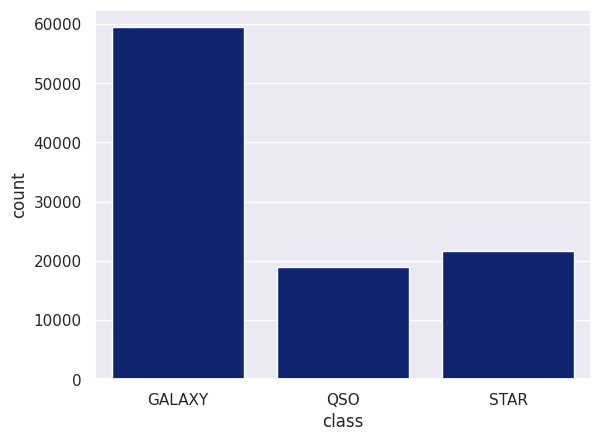

In [ ]:
sns.set(style='darkgrid', palette='dark')
sns.countplot(x=df['class'])
plt.show()

Preprocessing


In [ ]:
from numpy._core.fromnumeric import mean
# Handling Missing Values
# Fill missing values in all numerical columns with their mean
df=df.fillna(df.mean(numeric_only=True))

In [ ]:
df.isna().sum()

,0
obj_ID,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
run_ID,0
rerun_ID,0


Encoding

In [ ]:
# we can encode the data using label encoder
# class column is encoded to numerical values

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['class']=le.fit_transform(df['class'])

In [ ]:
df['class'].value_counts()

,count
class,
0,59445
2,21594
1,18961


Feature Selection

In [ ]:
df.columns

Index(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
       'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift',
       'plate', 'MJD', 'fiber_ID'],
      dtype='object')

In [ ]:
x=df[['u','g', 'r', 'i', 'z', 'redshift', 'plate']]
x

,u,g,r,i,z,redshift,plate
0,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,5812
1,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,10445
2,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,4576
3,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,9149
4,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,6121
...,...,...,...,...,...,...,...
99995,22.16759,22.97586,21.90404,21.30548,20.73569,0.000000,9374
99996,22.69118,22.38628,20.45003,19.75759,19.41526,0.404895,7626
99997,21.16916,19.26997,18.20428,17.69034,17.35221,0.143366,2764
99998,25.35039,21.63757,19.91386,19.07254,18.62482,0.455040,6751


In [ ]:
y=df['class']
y

,class
0,0
1,0
2,0
3,0
4,0
...,...
99995,0
99996,0
99997,0
99998,0


Splitting dataset


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,u,g,r,i,z,redshift,plate
75220,22.32247,21.40113,20.51302,19.62691,19.34791,0.659869,4562
48955,25.85486,24.22573,21.48514,20.38426,19.38826,0.813819,7735
44966,22.62750,21.41766,19.54710,18.87770,18.39861,0.404277,5317
13568,20.25937,18.53387,17.58141,17.16960,16.85448,0.108840,1954
92727,22.03892,21.46501,21.32925,21.26120,21.17124,-0.001039,3855
...,...,...,...,...,...,...,...
6265,20.82854,20.32382,20.25718,20.39426,20.36549,2.412806,10733
54886,18.93209,16.96611,16.05940,15.64639,15.30356,0.081128,1013
76820,23.95684,21.37612,19.75149,18.49137,17.77083,0.000253,3262
860,17.79224,16.47265,15.84970,15.59104,15.46414,0.000000,2679


Classification Algorithms

In [ ]:
# Creating the dataframe in which we'll store the matrices of all the classification algorithms so we can choose the best one.

score_df= pd.DataFrame(columns=['Algorithm','Accuracy score','Precision score', 'Recall score','F1 score'])

k-Nearest neighbors

In [ ]:
# Now, we'll create a dataframe where we'll store the matrices of the K Neighbors Classifier algorithm with different values of n_neighbors
# Then, we'll choose the maximum one and consider its respective 'i' as the number of neighbours of the KNN algo. for further use

knn_df=pd.DataFrame(columns=['Neighbours','Accuracy score','Precision score','Recall score','F1 score'])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
for i in range(3,11,2):
  model=KNeighborsClassifier(n_neighbors=i)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred,average='weighted')
  recall=recall_score(y_test,y_pred,average='weighted')
  f1=f1_score(y_test,y_pred,average='weighted')
  knn_df.loc[len(knn_df)]={'Neighbours':i,'Accuracy score':accuracy,'Precision score':precision,'Recall score':recall,'F1 score':f1}


In [ ]:
# DataFrame of Neighbours and their respective matrices
knn_df

,Neighbours,Accuracy score,Precision score,Recall score,F1 score
0,3,0.85985,0.859066,0.85985,0.855449
1,5,0.85290,0.852849,0.85290,0.846818
2,7,0.84785,0.848553,0.84785,0.840944
3,9,0.83985,0.841902,0.83985,0.831795


In [ ]:
# Number of neighbours=3
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train,y_train)
y_pred1=knn_model.predict(x_test)
knn_accuracy=accuracy_score(y_test,y_pred1)
knn_precision=precision_score(y_test,y_pred1,average='weighted')
knn_recall=recall_score(y_test,y_pred1,average='weighted')
knn_f1=f1_score(y_test,y_pred1,average='weighted')


In [ ]:
# Adding recall_score of the algo to the dataframe

score_df.loc[len(score_df)]={'Algorithm':'K-Nearest Neighbour','Accuracy score':knn_accuracy,'Precision score':knn_precision, 'Recall score': knn_recall, 'F1 score':knn_f1}
score_df

,Algorithm,Accuracy score,Precision score,Recall score,F1 score
0,K-Nearest Neighbour,0.85985,0.859066,0.85985,0.855449


Gaussian Naive Bayes.

In [ ]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train,y_train)
y_pred2=nb_model.predict(x_test)
nb_accuracy=accuracy_score(y_test,y_pred2)
nb_precision=precision_score(y_test,y_pred2,average='weighted')
nb_recall=recall_score(y_test,y_pred2,average='weighted')
nb_f1=f1_score(y_test,y_pred2,average='weighted')


In [ ]:
# Adding recall_score of the algo to the dataframe

score_df.loc[len(score_df)]={'Algorithm':'Gaussian Naive Bayse','Accuracy score':nb_accuracy,'Precision score':nb_precision, 'Recall score': nb_recall, 'F1 score':nb_f1}
score_df

,Algorithm,Accuracy score,Precision score,Recall score,F1 score
0,K-Nearest Neighbour,0.85985,0.859066,0.85985,0.855449
1,Gaussian Naive Bayse,0.70135,0.671666,0.70135,0.625487


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state = 30)
dt_model.fit(x_train, y_train)
y_pred3 = dt_model.predict(x_test)
dt_accuracy=accuracy_score(y_test,y_pred3)
dt_precision=precision_score(y_test,y_pred3,average='weighted')
dt_recall=recall_score(y_test,y_pred3,average='weighted')
dt_f1=f1_score(y_test,y_pred3,average='weighted')


In [ ]:
# Adding recall_score of the algo to the dataframe

score_df.loc[len(score_df)]={'Algorithm':'Decision Tree','Accuracy score':dt_accuracy,'Precision score':dt_precision, 'Recall score': dt_recall, 'F1 score':dt_f1}
score_df

,Algorithm,Accuracy score,Precision score,Recall score,F1 score
0,K-Nearest Neighbour,0.85985,0.859066,0.85985,0.855449
1,Gaussian Naive Bayse,0.70135,0.671666,0.70135,0.625487
2,Decision Tree,0.96620,0.966210,0.96620,0.966205


Confusion Metrics

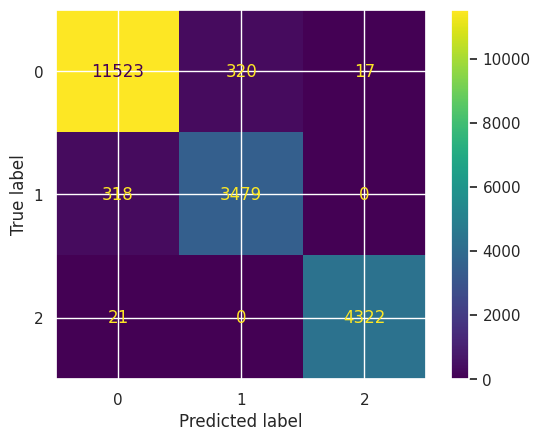

In [ ]:
# confusion metrics of Decision tree algorithm
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm=confusion_matrix(y_test,y_pred3)
cm_display=ConfusionMatrixDisplay(cm)
cm_display.plot()